In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

## Contrast / Illumination Enhancement

## 1. Load sample frames

In [2]:
frame_paths = [
    "../data/frames/selected/alligator_cracking/alligator_cracking_01_frame_310.jpg",
    "../data/frames/selected/edge_cracking/edge_cracking_03_frame_325.jpg",
    "../data/frames/selected/potholes/potholes_01_frame_25.jpg",
    "../data/frames/selected/transverse_cracking/transverse_cracking_01_frame_570.jpg",
]
images = []
names = []

for path in frame_paths:
    img = cv2.imread(path, 0)
    if img is None:
        print("Error loading:", path)
    else:
        images.append(img)
        names.append(os.path.basename(path))

print("Loaded", len(images), "frames")

Loaded 4 frames


In [3]:
def hist_eq(gray):
    return cv2.equalizeHist(gray)

def clahe(gray, clip):
    c = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
    return c.apply(gray)

def contrast_stretch(gray):
    g = gray.astype(np.float32)
    mn, mx = g.min(), g.max()
    if mx - mn < 1e-6:
        return gray
    out = (g - mn) * (255.0 / (mx - mn))
    return np.clip(out, 0, 255).astype(np.uint8)

def gamma_correction(gray, gamma=1.2):
    g = gray.astype(np.float32) / 255.0
    out = np.power(g, gamma) * 255.0
    return np.clip(out, 0, 255).astype(np.uint8)


def clahe_gamma(gray, clip=2.0, gamma=1.2):
    c = clahe(gray, clip)
    return gamma_correction(c, gamma)


In [4]:
def entropy(gray):
    hist = cv2.calcHist([gray],[0],None,[256],[0,256]).ravel()
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return float(-np.sum(p * np.log2(p)))

def mean_val(gray):
    return float(np.mean(gray))

def std_val(gray):
    return float(np.std(gray))

## 2. Visual comparison (in notebook)
Shows the outputs for each method on the same frame.

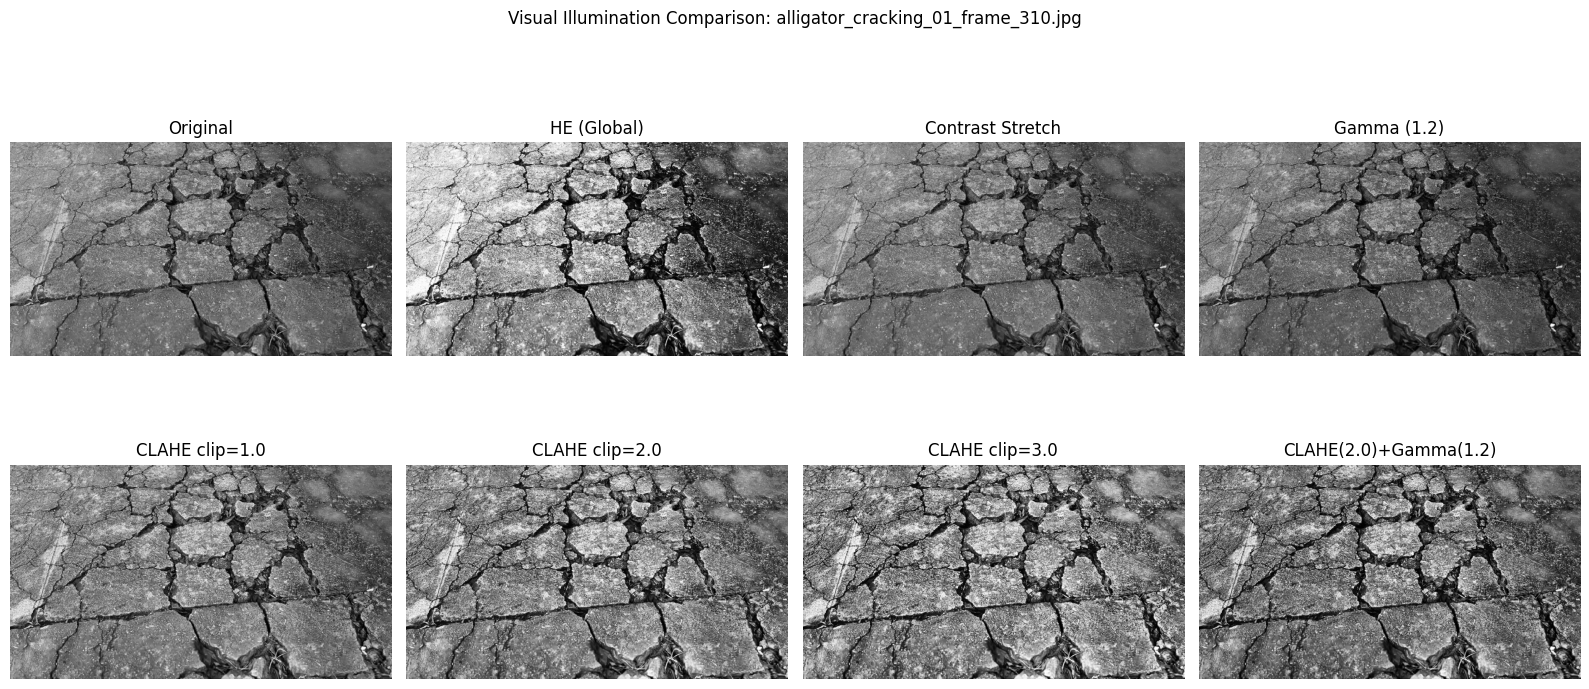

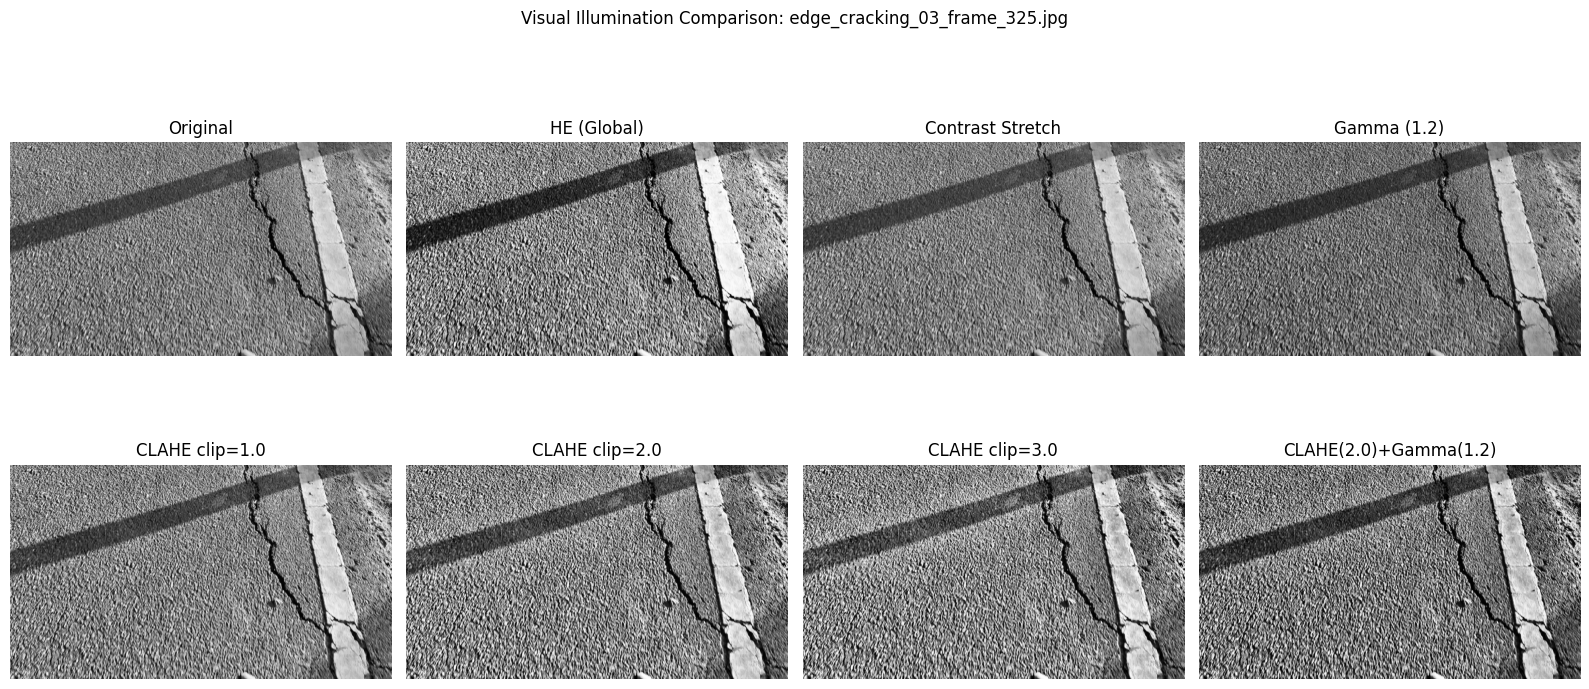

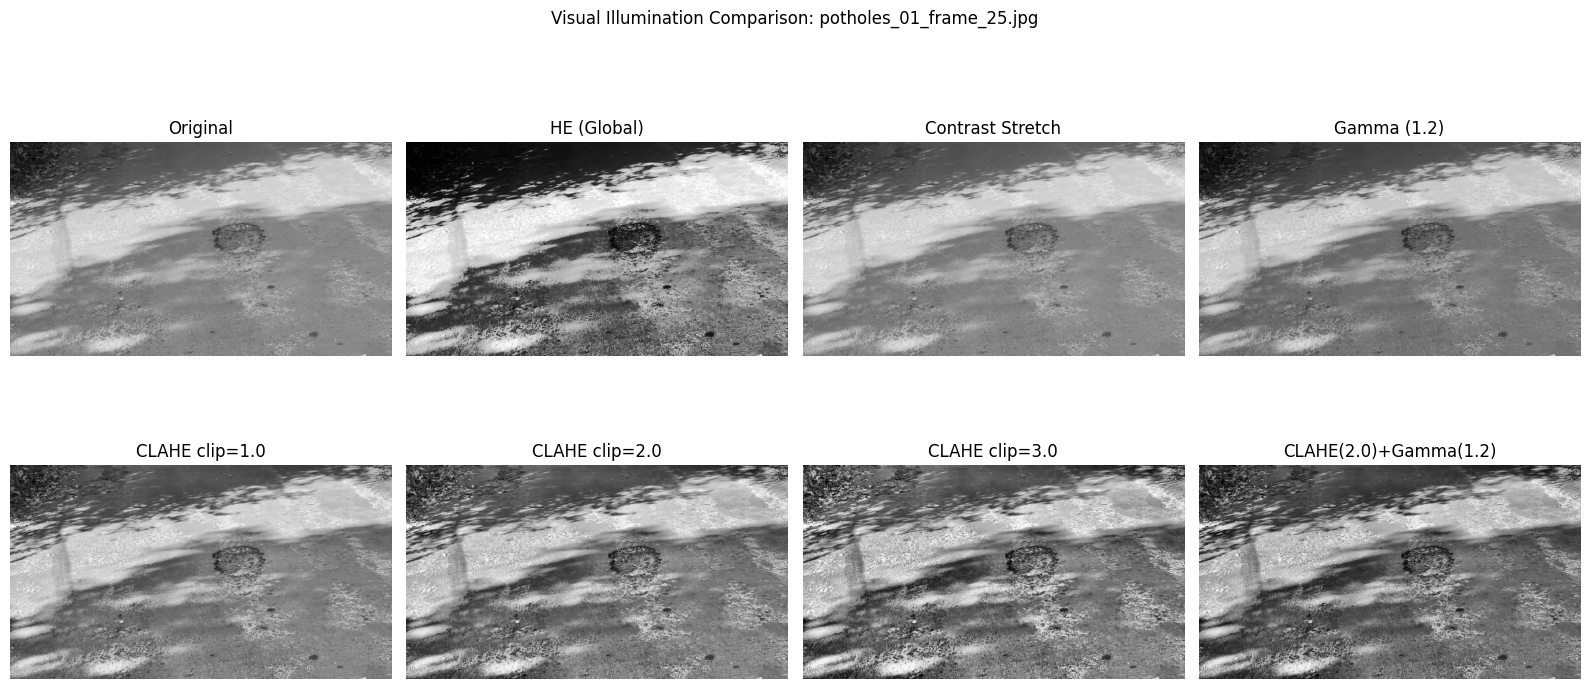

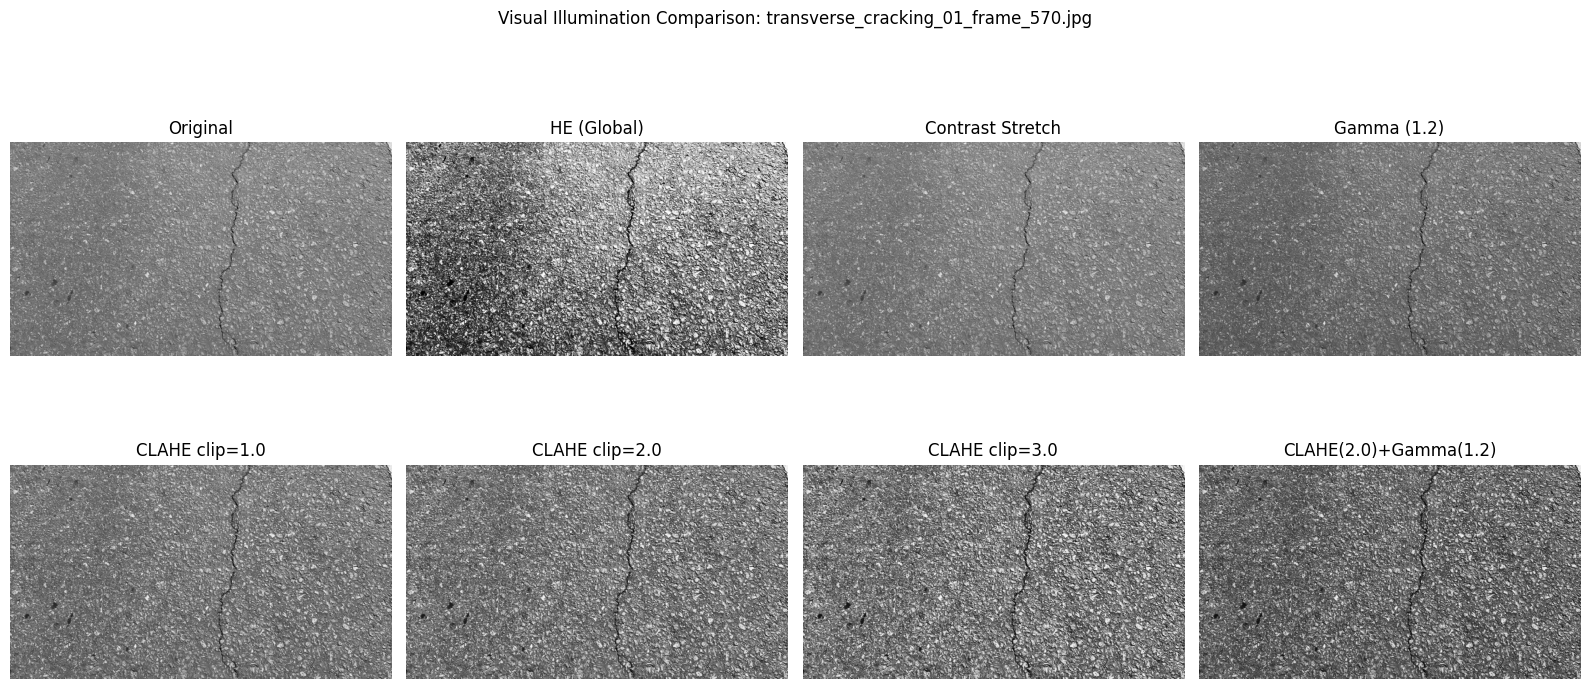

In [5]:
for img, nm in zip(images, names):
    he = hist_eq(img)
    cs = contrast_stretch(img)
    gm = gamma_correction(img, 1.2)
    c1 = clahe(img, 1.0)
    c2 = clahe(img, 2.0)
    c3 = clahe(img, 3.0)
    cg = clahe_gamma(img, clip=2.0, gamma=1.2)

    plt.figure(figsize=(16, 8))

    plt.subplot(2,4,1); plt.imshow(img, cmap="gray"); plt.title("Original"); plt.axis("off")
    plt.subplot(2,4,2); plt.imshow(he, cmap="gray"); plt.title("HE (Global)"); plt.axis("off")
    plt.subplot(2,4,3); plt.imshow(cs, cmap="gray"); plt.title("Contrast Stretch"); plt.axis("off")
    plt.subplot(2,4,4); plt.imshow(gm, cmap="gray"); plt.title("Gamma (1.2)"); plt.axis("off")

    plt.subplot(2,4,5); plt.imshow(c1, cmap="gray"); plt.title("CLAHE clip=1.0"); plt.axis("off")
    plt.subplot(2,4,6); plt.imshow(c2, cmap="gray"); plt.title("CLAHE clip=2.0"); plt.axis("off")
    plt.subplot(2,4,7); plt.imshow(c3, cmap="gray"); plt.title("CLAHE clip=3.0"); plt.axis("off")
    plt.subplot(2,4,8); plt.imshow(cg, cmap="gray"); plt.title("CLAHE(2.0)+Gamma(1.2)"); plt.axis("off")

    plt.suptitle("Visual Illumination Comparison: " + nm)
    plt.tight_layout()
    plt.show()


## 3. Histogram + metrics comparison

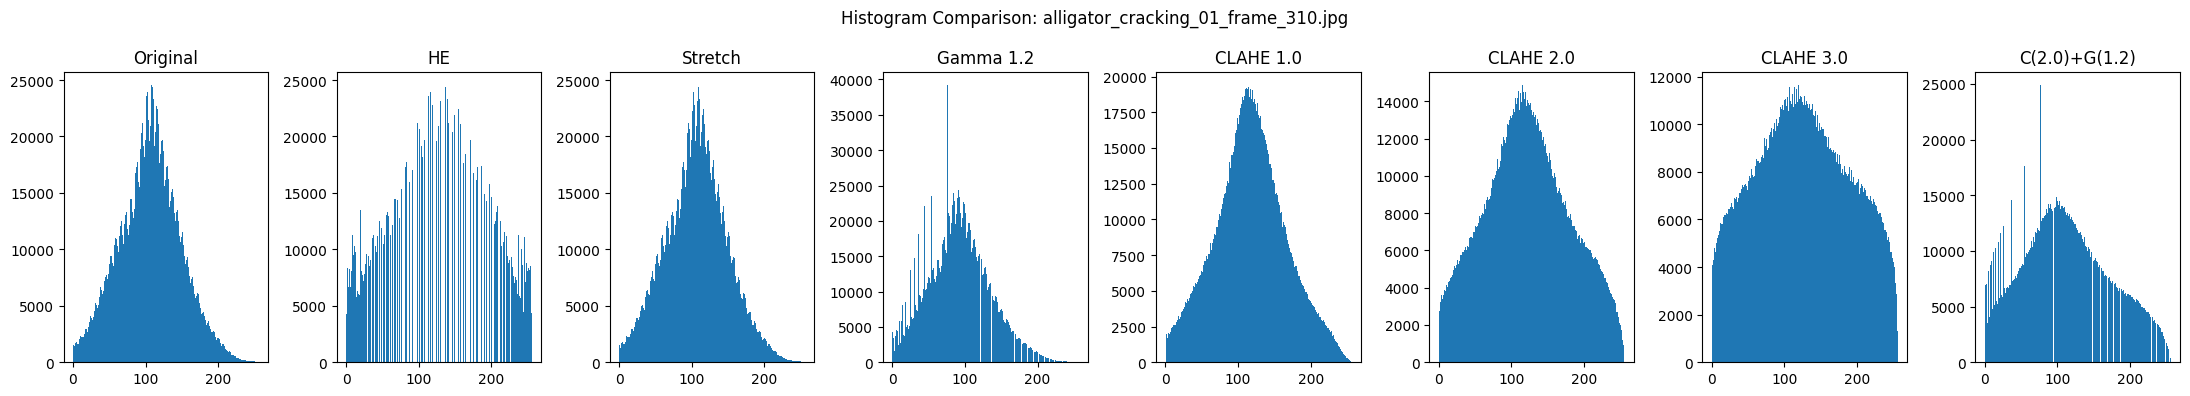

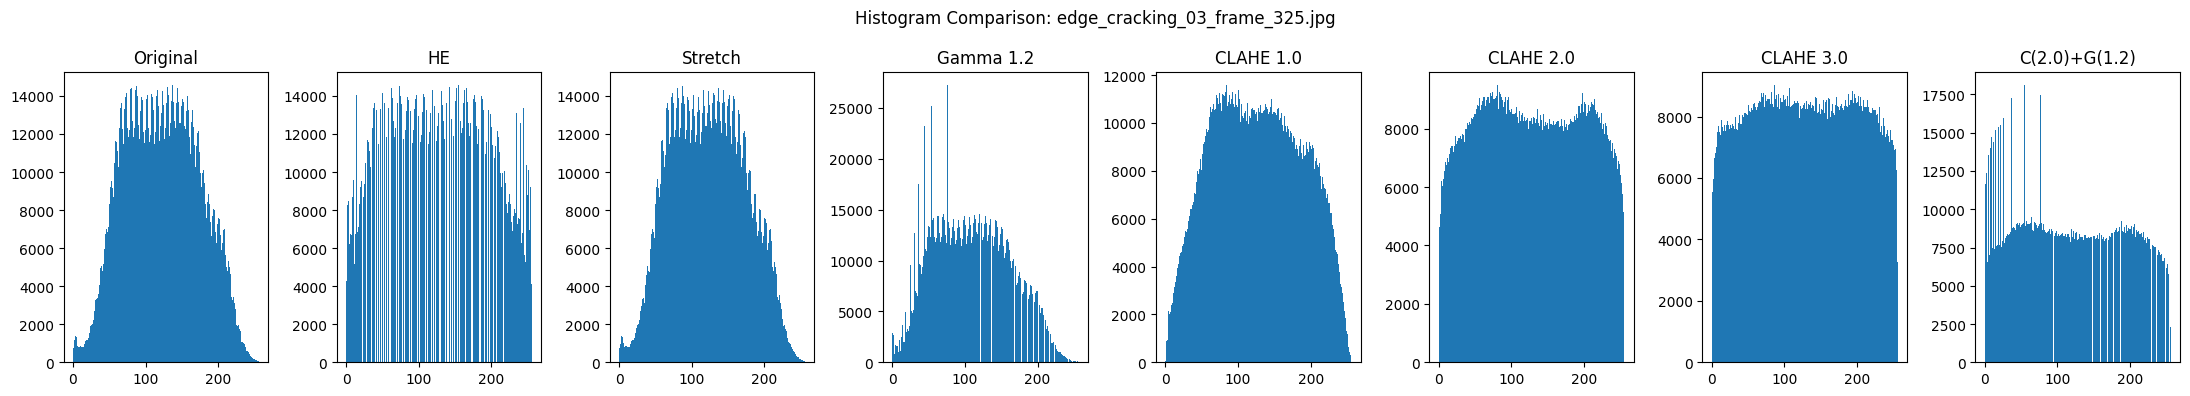

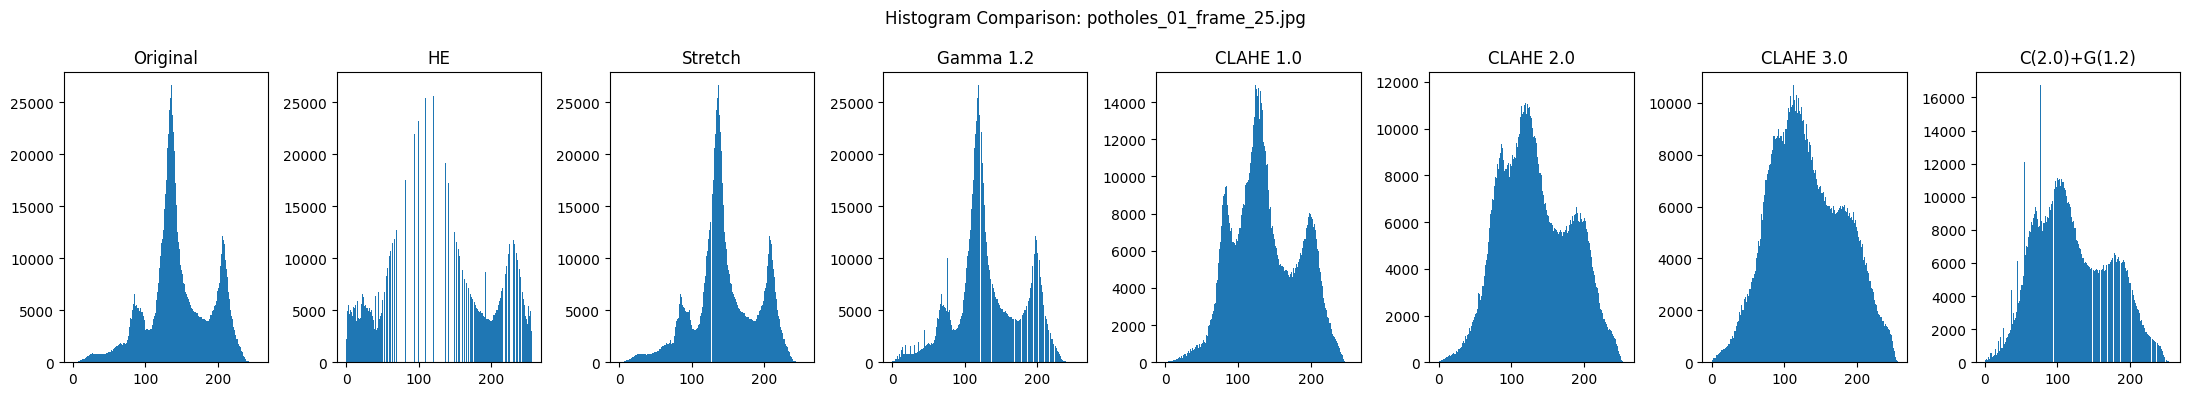

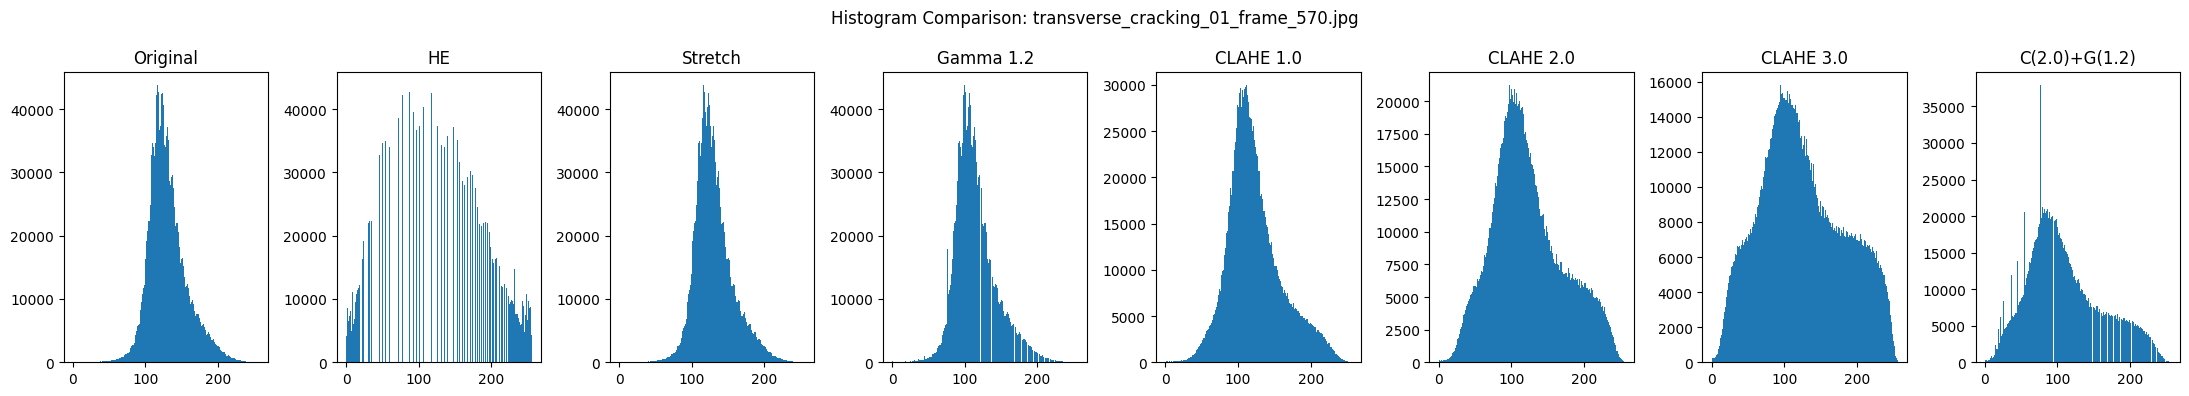

In [6]:
for img, nm in zip(images, names):
    he = hist_eq(img)
    cs = contrast_stretch(img)
    gm = gamma_correction(img, 1.2)
    c1 = clahe(img, 1.0)
    c2 = clahe(img, 2.0)
    c3 = clahe(img, 3.0)
    cg = clahe_gamma(img, clip=2.0, gamma=1.2)

    plt.figure(figsize=(22, 4))

    plt.subplot(1,8,1); plt.hist(img.ravel(), bins=256, range=(0,256)); plt.title("Original")
    plt.subplot(1,8,2); plt.hist(he.ravel(),  bins=256, range=(0,256)); plt.title("HE")
    plt.subplot(1,8,3); plt.hist(cs.ravel(),  bins=256, range=(0,256)); plt.title("Stretch")
    plt.subplot(1,8,4); plt.hist(gm.ravel(),  bins=256, range=(0,256)); plt.title("Gamma 1.2")
    plt.subplot(1,8,5); plt.hist(c1.ravel(),  bins=256, range=(0,256)); plt.title("CLAHE 1.0")
    plt.subplot(1,8,6); plt.hist(c2.ravel(),  bins=256, range=(0,256)); plt.title("CLAHE 2.0")
    plt.subplot(1,8,7); plt.hist(c3.ravel(),  bins=256, range=(0,256)); plt.title("CLAHE 3.0")
    plt.subplot(1,8,8); plt.hist(cg.ravel(),  bins=256, range=(0,256)); plt.title("C(2.0)+G(1.2)")

    plt.suptitle("Histogram Comparison: " + nm)
    plt.tight_layout()
    plt.show()


In [7]:
print("\n===== ILLUMINATION TEST DATA =====\n")

for img, nm in zip(images, names):

    print("Frame:", nm)
    print("Method                 Mean    STD     Entropy")
    print("------------------------------------------------")

    # Original
    print("Original             ",
          round(np.mean(img),2),
          round(np.std(img),2),
          round(entropy(img),2))

    # HE
    he = hist_eq(img)
    print("HE (Global)          ",
          round(np.mean(he),2),
          round(np.std(he),2),
          round(entropy(he),2))

    # Contrast Stretch
    cs = contrast_stretch(img)
    print("Contrast Stretch     ",
          round(np.mean(cs),2),
          round(np.std(cs),2),
          round(entropy(cs),2))

    # Gamma
    gm = gamma_correction(img, 1.2)
    print("Gamma (1.2)          ",
          round(np.mean(gm),2),
          round(np.std(gm),2),
          round(entropy(gm),2))

    # CLAHE tests
    for clip in [1.0, 2.0, 3.0]:
        c = clahe(img, clip)
        print(f"CLAHE({clip})           ",
              round(np.mean(c),2),
              round(np.std(c),2),
              round(entropy(c),2))

    # CLAHE + Gamma
    cg = clahe_gamma(img, clip=2.0, gamma=1.2)
    print("CLAHE(2.0)+Gamma(1.2) ",
          round(np.mean(cg),2),
          round(np.std(cg),2),
          round(entropy(cg),2))

    print("\n")



===== ILLUMINATION TEST DATA =====

Frame: alligator_cracking_01_frame_310.jpg
Method                 Mean    STD     Entropy
------------------------------------------------
Original              106.06 42.3 7.43
HE (Global)           128.3 73.67 7.23
Contrast Stretch      106.06 42.3 7.43
Gamma (1.2)           90.28 42.15 7.33
CLAHE(1.0)            116.92 48.62 7.62
CLAHE(2.0)            122.28 58.61 7.85
CLAHE(3.0)            125.41 65.34 7.95
CLAHE(2.0)+Gamma(1.2)  108.19 60.04 7.76


Frame: edge_cracking_03_frame_325.jpg
Method                 Mean    STD     Entropy
------------------------------------------------
Original              122.41 50.58 7.65
HE (Global)           128.13 73.6 7.5
Contrast Stretch      122.41 50.58 7.65
Gamma (1.2)           107.46 52.02 7.58
CLAHE(1.0)            126.22 61.06 7.87
CLAHE(2.0)            127.74 71.14 7.99
CLAHE(3.0)            127.96 71.9 7.99
CLAHE(2.0)+Gamma(1.2)  115.28 73.11 7.86


Frame: potholes_01_frame_25.jpg
Method             

In [8]:
categories = [
    "alligator_cracking",
    "edge_cracking",
    "potholes",
    "transverse_cracking"
]

BEST_METHOD = "clahe"
BEST_CLIP = 2.0        

for category in categories:
    input_folder  = f"../data/frames/enhanced/noise_removed/{category}"
    output_folder = f"../data/frames/enhanced/contrast_enhanced/{category}"
    os.makedirs(output_folder, exist_ok=True)

    for file in os.listdir(input_folder):
        img_path = os.path.join(input_folder, file)
        img = cv2.imread(img_path, 0)

        if img is not None:
            if BEST_METHOD == "he":
                out = hist_eq(img)
            elif BEST_METHOD == "stretch":
                out = contrast_stretch(img)
            else:
                out = clahe(img, BEST_CLIP)

            cv2.imwrite(os.path.join(output_folder, file), out)

    print("DONE:", category)

print("All categories illumination enhancement completed.")

DONE: alligator_cracking
DONE: edge_cracking
DONE: potholes
DONE: transverse_cracking
All categories illumination enhancement completed.


## 4. Report evidence export

In [9]:
import csv

REPORT_DIR = "../results/report_evidence/contrast"
os.makedirs(REPORT_DIR, exist_ok=True)

def enhance(img):
    return clahe(img, 2.0)

def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()


for img, nm in zip(images, names):

    out = enhance(img)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(out, cmap="gray")
    plt.title("After CLAHE(2.0)")
    plt.axis("off")

    plt.suptitle(nm)

    save_path = os.path.join(REPORT_DIR, nm.replace(".jpg","")+"_before_after.png")
    save_fig(save_path)

print("Saved before/after images")


for img, nm in zip(images, names):

    out = enhance(img)

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.hist(img.ravel(), bins=256, range=(0,256))
    plt.title("Histogram - Original")

    plt.subplot(1,2,2)
    plt.hist(out.ravel(), bins=256, range=(0,256))
    plt.title("Histogram - CLAHE(2.0)")

    plt.suptitle("Histogram Comparison: "+nm)

    save_path = os.path.join(REPORT_DIR, nm.replace(".jpg","")+"_hist_compare.png")
    save_fig(save_path)

print("Saved histogram comparisons")


csv_path = os.path.join(REPORT_DIR,"contrast_metrics.csv")

with open(csv_path,"w",newline="") as f:

    writer = csv.writer(f)

    writer.writerow(["frame","mean_before","mean_after","std_before","std_after"])

    for img,nm in zip(images,names):

        out = enhance(img)

        writer.writerow([
            nm,
            float(np.mean(img)),
            float(np.mean(out)),
            float(np.std(img)),
            float(np.std(out))
        ])

print("Saved metrics CSV:", csv_path)

Saved before/after images
Saved histogram comparisons
Saved metrics CSV: ../results/report_evidence/contrast\contrast_metrics.csv
